# Test 1: Circle / Semi-Circle DMPS and Kernel EDMD-KSWGD

This notebook merges the previous DMPS and Kernel EDMD-KSWGD circle/semi-circle notebooks. Change the shared controls below to switch between full circle and upper semi-circle experiments.


In [1]:
# Shared controls for both sections
# Default is the full circle. Set USE_SEMICIRCLE = True for the upper semi-circle.
USE_SEMICIRCLE = False

SPHERE_RANDOM_SEED = 0
SPHERE_N_TARGET = 500
SPHERE_DIM = 2
SPHERE_ANISOTROPY = 1.0
SPHERE_NUM_ITER = 1000
SPHERE_STEP_SIZE = 2.0
SPHERE_INIT_PARTICLES = 700

# Kernel EDMD section only: 1=RBF, 2=Spherical, 3=Matern, 4=Rational Quadratic, 5=Polynomial.
SPHERE_KERNEL_TYPE = 5


## A. DMPS on Circle / Semi-Circle


## 1. Import Libraries and GPU/CPU Backend Configuration

In [2]:
# This is a Gaussian example as a proof of concept.
import numpy as np
from scipy.linalg import svd
import matplotlib.pyplot as plt
import pandas as pd
import time

# --------------- Optional GPU backend (CuPy) ---------------
USE_GPU = True  # set False to force CPU even if CuPy is available
try:  # Attempt to import cupy
    import cupy as cp  # type: ignore
    GPU_AVAILABLE = True
except Exception:
    cp = None  # type: ignore
    GPU_AVAILABLE = False
USE_GPU = bool(USE_GPU and GPU_AVAILABLE)
if USE_GPU:
    from grad_ker1_gpu import grad_ker1  # xp-aware versions
    from K_tar_eval_gpu import K_tar_eval
else:
    from grad_ker1 import grad_ker1      # CPU fallbacks
    from K_tar_eval import K_tar_eval

print(f"[DEVICE] {'GPU' if USE_GPU else 'CPU'} mode active")

[DEVICE] GPU mode active


In [3]:
# --- Plot polish settings (visual only) ---
# This cell only controls figure appearance. It does not change sampling, kernels, spectra, or metrics.
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

PAPER_DPI = 160
EXPORT_DPI = 300

plt.rcParams.update({
    'figure.dpi': PAPER_DPI,
    'savefig.dpi': EXPORT_DPI,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.03,
    'font.family': 'DejaVu Sans',
    'mathtext.fontset': 'dejavusans',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'axes.linewidth': 0.9,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'image.interpolation': 'nearest',
})

def polish_axes(ax, *, equal=False, grid=False):
    """Apply consistent visual-only axis styling."""
    if equal:
        ax.set_aspect('equal', adjustable='box')
    ax.tick_params(direction='in', length=3, width=0.8)
    if grid:
        ax.grid(True, alpha=0.22, linestyle='--', linewidth=0.6)
    for spine in ax.spines.values():
        spine.set_linewidth(0.9)
        spine.set_color('0.25')
    return ax

def polish_legend(ax, **kwargs):
    """Draw a compact legend only when labelled artists exist."""
    handles, labels = ax.get_legend_handles_labels()
    labels = [label for label in labels if label and not label.startswith('_')]
    if labels:
        defaults = dict(frameon=True, framealpha=0.92, edgecolor='0.85')
        defaults.update(kwargs)
        return ax.legend(**defaults)
    return None

def set_pi_ticks(ax):
    ticks = [0, np.pi, 2 * np.pi]
    labels = ['0', r'$\pi$', r'$2\pi$']
    ax.set_xticks(ticks)
    ax.set_xticklabels(labels)
    ax.set_yticks(ticks)
    ax.set_yticklabels(labels)
    return ax


## 2. Define Timing and Progress Utility Functions

In [4]:
# ---------------- Timing / Progress Utilities ----------------
def _fmt_secs(s: float) -> str:
    s = max(0.0, float(s))
    h = int(s // 3600)
    m = int((s % 3600) // 60)
    sec = int(s % 60)
    if h > 0:
        return f"{h:02d}:{m:02d}:{sec:02d}"
    return f"{m:02d}:{sec:02d}"

def _print_phase(name: str, t_start: float) -> float:
    dt = time.time() - t_start
    print(f"[TIMER] {name}: {dt:.3f}s")
    return time.time()

_LAST_PROGRESS_LEN = 0
def _print_progress(curr: int, total: int, start_time: float, prefix: str = "") -> None:
    global _LAST_PROGRESS_LEN
    total = max(1, int(total))
    curr = min(max(0, curr), total)
    bar_len = 30
    filled = int(bar_len * curr / total)
    filled = min(filled, bar_len)
    bar = ("=" * filled) + (">" if filled < bar_len else "") + ("." * max(0, bar_len - filled - (0 if filled == bar_len else 1)))
    pct = 100.0 * curr / total
    elapsed = time.time() - start_time
    avg = elapsed / max(1, curr)
    eta = avg * (total - curr)
    msg = f"{prefix}[{bar}] {pct:5.1f}% | iter {curr}/{total} | elapsed {_fmt_secs(elapsed)} | eta {_fmt_secs(eta)}"
    prev = _LAST_PROGRESS_LEN
    clear = "\r" + (" " * prev) + "\r"
    print(clear, end="")
    print(msg, end="", flush=True)
    _LAST_PROGRESS_LEN = len(msg)

## 3. Configuration Parameters

- `USE_SEMICIRCLE`: True for semi-circle, False for full circle
- `n`: Number of target sample points (500)
- `d`: Dimensions (2D)
- `lambda_`: Anisotropy parameter (1 means isotropic)

In [5]:
# Set random seed for reproducibility (optional)
np.random.seed(SPHERE_RANDOM_SEED)
_t = time.time()

# ---------------- Configuration ----------------
USE_SEMICIRCLE = bool(globals().get('USE_SEMICIRCLE', False))  # False: full circle; True: upper semi-circle

# Sample 500 points from a circle or semi-circle
n = int(globals().get('SPHERE_N_TARGET', 500))
d = int(globals().get('SPHERE_DIM', 2))
lambda_ = float(globals().get('SPHERE_ANISOTROPY', 1.0))  # 1.0 is isotropic
# NOTE: lambda_ = 1 means NO anisotropy (isotropic circle)
# Set lambda_ > 1 to create non-uniform distribution with more points near y-axis

## 4. Generate Target Distribution Samples (Circle/Semi-Circle)

Two sampling methods available:
- **Method 1 (Currently Used)**: Rejection sampling - Gaussian sampling + normalization + filtering
- **Method 2 (Alternative)**: Polar coordinate sampling - Direct angle sampling converted to Cartesian coordinates

In [6]:
if USE_SEMICIRCLE:
    # ============================================================
    # METHOD 1: Rejection Sampling (same basis as full sphere)
    # ============================================================
    # This method uses the same Gaussian sampling + normalization as the full circle,
    # but filters to keep only points in the upper semi-circle (y >= 0).
    # Pros: Maintains same statistical properties as full circle method
    # Cons: Less efficient (rejects ~50% of samples)
    
    samples = []
    while len(samples) < n:
        # Over-sample to reduce number of rejection rounds
        batch_size = max(n - len(samples), int((n - len(samples)) * 2.5))
        
        # Gaussian sampling (same as full circle)
        u = np.random.normal(0, 1, (batch_size, d))
        u[:, 0] = lambda_ * u[:, 0]  # Apply anisotropy
        u_norm = np.linalg.norm(u, axis=1, keepdims=True)
        u_trans = u / (u_norm + 1e-12)
        
        # Rejection step: keep only upper semi-circle points
        valid = u_trans[:, 1] >= 0  # Filter for y >= 0
        samples.append(u_trans[valid, :])
    
    u_trans = np.vstack(samples)[:n, :]  # Take exactly n samples
    label = "semi-circle"
    
    # ============================================================
    # METHOD 2: Polar Coordinate Sampling 
    # ============================================================
    # This method directly samples angles in [0, π] and converts to Cartesian.
    # Pros: More efficient, more intuitive, flexible angle range
    # Cons: Different sampling method from full circle (not Gaussian-based)
    
    # theta = np.random.uniform(0, np.pi, (n, 1))
    # u_trans = np.hstack([
    #     np.cos(theta),  # x = cos(θ)
    #     np.sin(theta)   # y = sin(θ), ensures y >= 0
    # ])
    # 
    # # Apply anisotropy (stretch along x-axis)
    # u_trans[:, 0] = lambda_ * u_trans[:, 0]
    # u_norm = np.linalg.norm(u_trans, axis=1, keepdims=True)
    # u_trans = u_trans / (u_norm + 1e-12)
    # 
    # label = "semi-circle"
    
else:
    # ============================================================
    # METHOD 1: Gaussian Sampling (Marsaglia Method)
    # ============================================================
    # This method uses Gaussian sampling + normalization.
    # Pros: Generalizes to higher dimensions (3D, 4D, etc.)
    # Cons: Less intuitive, no explicit angle representation
    
    u = np.random.normal(0, 1, (n, d))
    u[:, 0] = lambda_ * u[:, 0]  # Apply anisotropy
    u_norm = np.linalg.norm(u, axis=1, keepdims=True)
    u_trans = u / (u_norm + 1e-12)
    
    label = "full circle"

    # ============================================================
    # METHOD 2: Polar Coordinate Sampling (RECOMMENDED)
    # ============================================================
    # Directly sample angles uniformly in [0, 2π] and convert to Cartesian.
    # Pros: Intuitive, efficient, explicitly angle-based
    # Cons: None for 2D case
    
    # theta = np.random.uniform(0, 2 * np.pi, (n, 1))
    # u_trans = np.hstack([
    #     np.cos(theta),  # x = cos(θ)
    #     np.sin(theta)   # y = sin(θ)
    # ])
    
    # # Apply anisotropy (stretch along x-axis) - Optional
    # # WARNING: This breaks the uniform angular distribution!
    # # After stretching and re-normalizing, points cluster near y-axis when lambda_ > 1
    # if lambda_ != 1:
    #     u_trans[:, 0] = lambda_ * u_trans[:, 0]
    #     u_norm = np.linalg.norm(u_trans, axis=1, keepdims=True)
    #     u_trans = u_trans / (u_norm + 1e-12)
    #     label = f"full circle (anisotropic λ={lambda_})"
    # else:
    #     label = "full circle (uniform)"

# Radial distance: slightly randomized around radius 1 (creates a thin annulus)
r = np.sqrt(np.random.rand(n, 1)) * 1/100 + 99/100
X_tar = r * u_trans
_t = _print_phase(f"Target sample generation ({label})", _t)
n = X_tar.shape[0]

[TIMER] Target sample generation (full circle): 0.011s


## 5. Build Gaussian Kernel Matrix and Normalization

Steps:
1. Compute Euclidean distances between sample points
2. Adaptively determine bandwidth parameter `epsilon`
3. Build Gaussian kernel matrix
4. Density normalization
5. Random-walk symmetric normalization

In [7]:
# Form the anisotropic graph Laplacian
sq_tar = np.sum(X_tar ** 2, axis=1)
H = sq_tar[:, None] + sq_tar[None, :] - 2 * (X_tar @ X_tar.T)
# epsilon = 0.5 * np.median(H) / np.log(n + 1)
epsilon = 1e-1
def ker(X):
    sq_tar = np.sum(X ** 2, axis=1)
    return np.exp(-(sq_tar[:, None] + sq_tar[None, :] - 2 * (X @ X.T)) / (2 * epsilon))

data_kernel = ker(X_tar)
_t = _print_phase("Base kernel (Gaussian) build", _t)
p_x = np.sqrt(np.sum(data_kernel, axis=1))
p_y = p_x.copy()
# Normalize kernel
data_kernel_norm = data_kernel / p_x[:, None] / p_y[None, :]
D_y = np.sum(data_kernel_norm, axis=0)

# Match MATLAB: 0.5*(A ./ D_y + A ./ D_y') where D_y is a row vector.
# First term divides columns by D_y (broadcast over last axis),
# second term explicitly divides rows by D_y (reshape as column vector).
rw_kernel = 0.5 * (data_kernel_norm / D_y + data_kernel_norm / D_y[:, None])
_t = _print_phase("Random-walk symmetric normalization", _t)

[TIMER] Base kernel (Gaussian) build: 0.025s
[TIMER] Random-walk symmetric normalization: 0.004s


## 6. SVD Decomposition and Inverse Kernel Computation

Extract spectral information from the kernel matrix via singular value decomposition, and compute regularized inverse weights for gradient calculations.

In [8]:
phi, s, _ = svd(rw_kernel)
_t = _print_phase("SVD on rw_kernel", _t)
lambda_ns = s
lambda_ = -lambda_ns + 1
inv_lambda = np.zeros_like(lambda_)
inv_lambda[1:] = 1 / lambda_[1:]
inv_lambda = inv_lambda * epsilon
inv_K = phi @ np.diag(inv_lambda) @ phi.T
_t = _print_phase("Primary inverse-like weights (inv_lambda)", _t)

tol = 1e-6
lambda_ns_mod = np.copy(lambda_ns)
lambda_ns_mod[lambda_ns_mod < tol] = 0
below_tol = np.sum(lambda_ns < tol)
above_tol = n - below_tol
reg = 0.001
lambda_ns_inv = np.zeros_like(lambda_ns)
mask = lambda_ns >= tol
lambda_ns_inv[mask] = epsilon / (lambda_ns[mask] + reg)
inv_K_ns = phi @ np.diag(lambda_ns_inv) @ phi.T
_t = _print_phase("Regularized inverse weights (lambda_ns_inv)", _t)

[TIMER] SVD on rw_kernel: 0.076s


[TIMER] Primary inverse-like weights (inv_lambda): 0.192s
[TIMER] Regularized inverse weights (lambda_ns_inv): 0.008s


## 7. Particle Initialization

- `iter`: Number of iterations = 1000
- `h`: Step size = 2
- `m`: Initial number of particles ≈ 700
- Filter particle initial positions based on mode (full circle/semi-circle)

In [9]:
# Run algorithm
iter = int(globals().get('SPHERE_NUM_ITER', 1000))
h = float(globals().get('SPHERE_STEP_SIZE', 2.0))
m = int(globals().get('SPHERE_INIT_PARTICLES', 700))
u = np.random.normal(0, 1, (m, d))
u_norm = np.linalg.norm(u, axis=1, keepdims=True)
r = np.sqrt(np.random.rand(m, 1)) * 1/100 + 99/100
u_trans = u / u_norm
x_init = r * u_trans
# x_init = x_init[x_init[:, 1] > 0.95, :]

# Particle initialization strategy based on mode
if USE_SEMICIRCLE:
    # Semi-circle: only upper hemisphere (y > 0.9)
    x_init = x_init[x_init[:, 1] > 0.9, :]
else:
    # Full circle: both upper (y > 0.9) AND lower (y < -0.9) hemispheres
    x_init = x_init[x_init[:, 1] > 0.95, :]

m = x_init.shape[0]
x_t = np.zeros((m, d, iter), dtype=np.float64)  # Use float64 for precision
x_t[:, :, 0] = x_init
_t = _print_phase("Particle initialization", _t)

p_tar = np.sum(data_kernel, axis=0)
D = np.sum(data_kernel / np.sqrt(p_tar) / np.sqrt(p_tar)[:, None], axis=1)

inv_K_ns_s_ns = phi @ np.diag(lambda_ns_inv * inv_lambda * lambda_ns_inv) @ phi.T
lambda_s_s_ns = inv_lambda * inv_lambda * lambda_ns_inv
lambda_s_s_ns = lambda_s_s_ns[:above_tol]
lambda_ns_s_ns = lambda_ns_inv * inv_lambda * lambda_ns_inv
lambda_ns_s_ns = lambda_ns_s_ns[:above_tol]

print(f"Number of particles: {m}")
print(f"Effective eigenvalues: {above_tol} / {n}")

[TIMER] Particle initialization: 0.009s
Number of particles: 76
Effective eigenvalues: 52 / 500


## 8. DMPS Iteration Loop

Core algorithm: $x_{t+1} = x_t - \frac{h}{m} \nabla K(x_t, X_{\text{tar}})$

Supports both GPU and CPU modes with progress bar display.

In [10]:
sum_x = np.zeros((m, d))
loop_start = time.time()
total_loop = iter - 1

if USE_GPU:
    # Stage constants on GPU (keep float64 for precision)
    X_tar_gpu = cp.asarray(X_tar)
    p_tar_gpu = cp.asarray(p_tar)
    sq_tar_gpu = cp.asarray(sq_tar)
    D_gpu = cp.asarray(D)
    phi_gpu = cp.asarray(phi[:, :above_tol])
    lambda_ns_s_ns_gpu = cp.asarray(lambda_ns_s_ns)
    x_t_gpu = cp.asarray(x_t)
    diag_lambda_gpu = cp.diag(lambda_ns_s_ns_gpu)
    
    # Iteration loop (GPU)
    for t in range(iter - 1):
        x_slice = x_t_gpu[:, :, t]
        grad_matrix = grad_ker1(x_slice, X_tar_gpu, p_tar_gpu, sq_tar_gpu, D_gpu, epsilon)
        cross_matrix = K_tar_eval(X_tar_gpu, x_slice, p_tar_gpu, sq_tar_gpu, D_gpu, epsilon)
        
        # Original full-sphere algorithm (per-dimension loop)
        sum_x_gpu = cp.zeros((m, d))
        for i in range(d):
            sum_x_gpu[:, i] = cp.sum(
                grad_matrix[:, :, i] @ phi_gpu @ diag_lambda_gpu @ phi_gpu.T @ cross_matrix,
                axis=1
            )
        
        x_t_gpu[:, :, t + 1] = x_slice - (h / m) * sum_x_gpu
        done = t + 1
        if done == total_loop or (done % max(1, total_loop // 100) == 0):
            _print_progress(done, total_loop, loop_start, prefix="[DMPS-FULL-GPU] ")
    
    x_t = cp.asnumpy(x_t_gpu)
else:
    # CPU iteration loop
    for t in range(iter - 1):
        grad_matrix = grad_ker1(x_t[:, :, t], X_tar, p_tar, sq_tar, D, epsilon)
        cross_matrix = K_tar_eval(X_tar, x_t[:, :, t], p_tar, sq_tar, D, epsilon)
        for i in range(d):
            sum_x[:, i] = np.sum(
                grad_matrix[:, :, i] @ phi[:, :above_tol] @ np.diag(lambda_ns_s_ns) @ phi[:, :above_tol].T @ cross_matrix,
                axis=1
            )
        x_t[:, :, t + 1] = x_t[:, :, t] - h / m * sum_x
        done = t + 1
        if done == total_loop or (done % max(1, total_loop // 100) == 0):
            _print_progress(done, total_loop, loop_start, prefix="[DMPS-FULL-CPU] ")

print()
_t = _print_phase("Iteration loop total", loop_start)

[DMPS-FULL-GPU] [>.............................]   0.9% | iter 9/999 | elapsed 00:01 | eta 03:05

[DMPS-FULL-GPU] [>.............................]   1.8% | iter 18/999 | elapsed 00:01 | eta 01:32

[DMPS-FULL-GPU] [>.............................]   2.7% | iter 27/999 | elapsed 00:01 | eta 01:01

[DMPS-FULL-GPU] [=>............................]   3.6% | iter 36/999 | elapsed 00:01 | eta 00:46

[DMPS-FULL-GPU] [=>............................]   4.5% | iter 45/999 | elapsed 00:01 | eta 00:37

...

[DMPS-FULL-GPU] [=============================>]  97.3% | iter 972/999 | elapsed 00:03 | eta 00:00

[DMPS-FULL-GPU] [=============================>]  98.2% | iter 981/999 | elapsed 00:03 | eta 00:00

[DMPS-FULL-GPU] [=============================>]  99.1% | iter 990/999 | elapsed 00:03 | eta 00:00

[DMPS-FULL-GPU] [==============================] 100.0% | iter 999/999 | elapsed 00:03 | eta 00:00


[TIMER] Iteration loop total: 3.531s


## 9. Visualization of Results (2D/3D)

- **Blue dots**: Target distribution (`X_tar`)
- **Red solid circles**: Initial particle positions
- **Magenta hollow circles**: Final particle positions

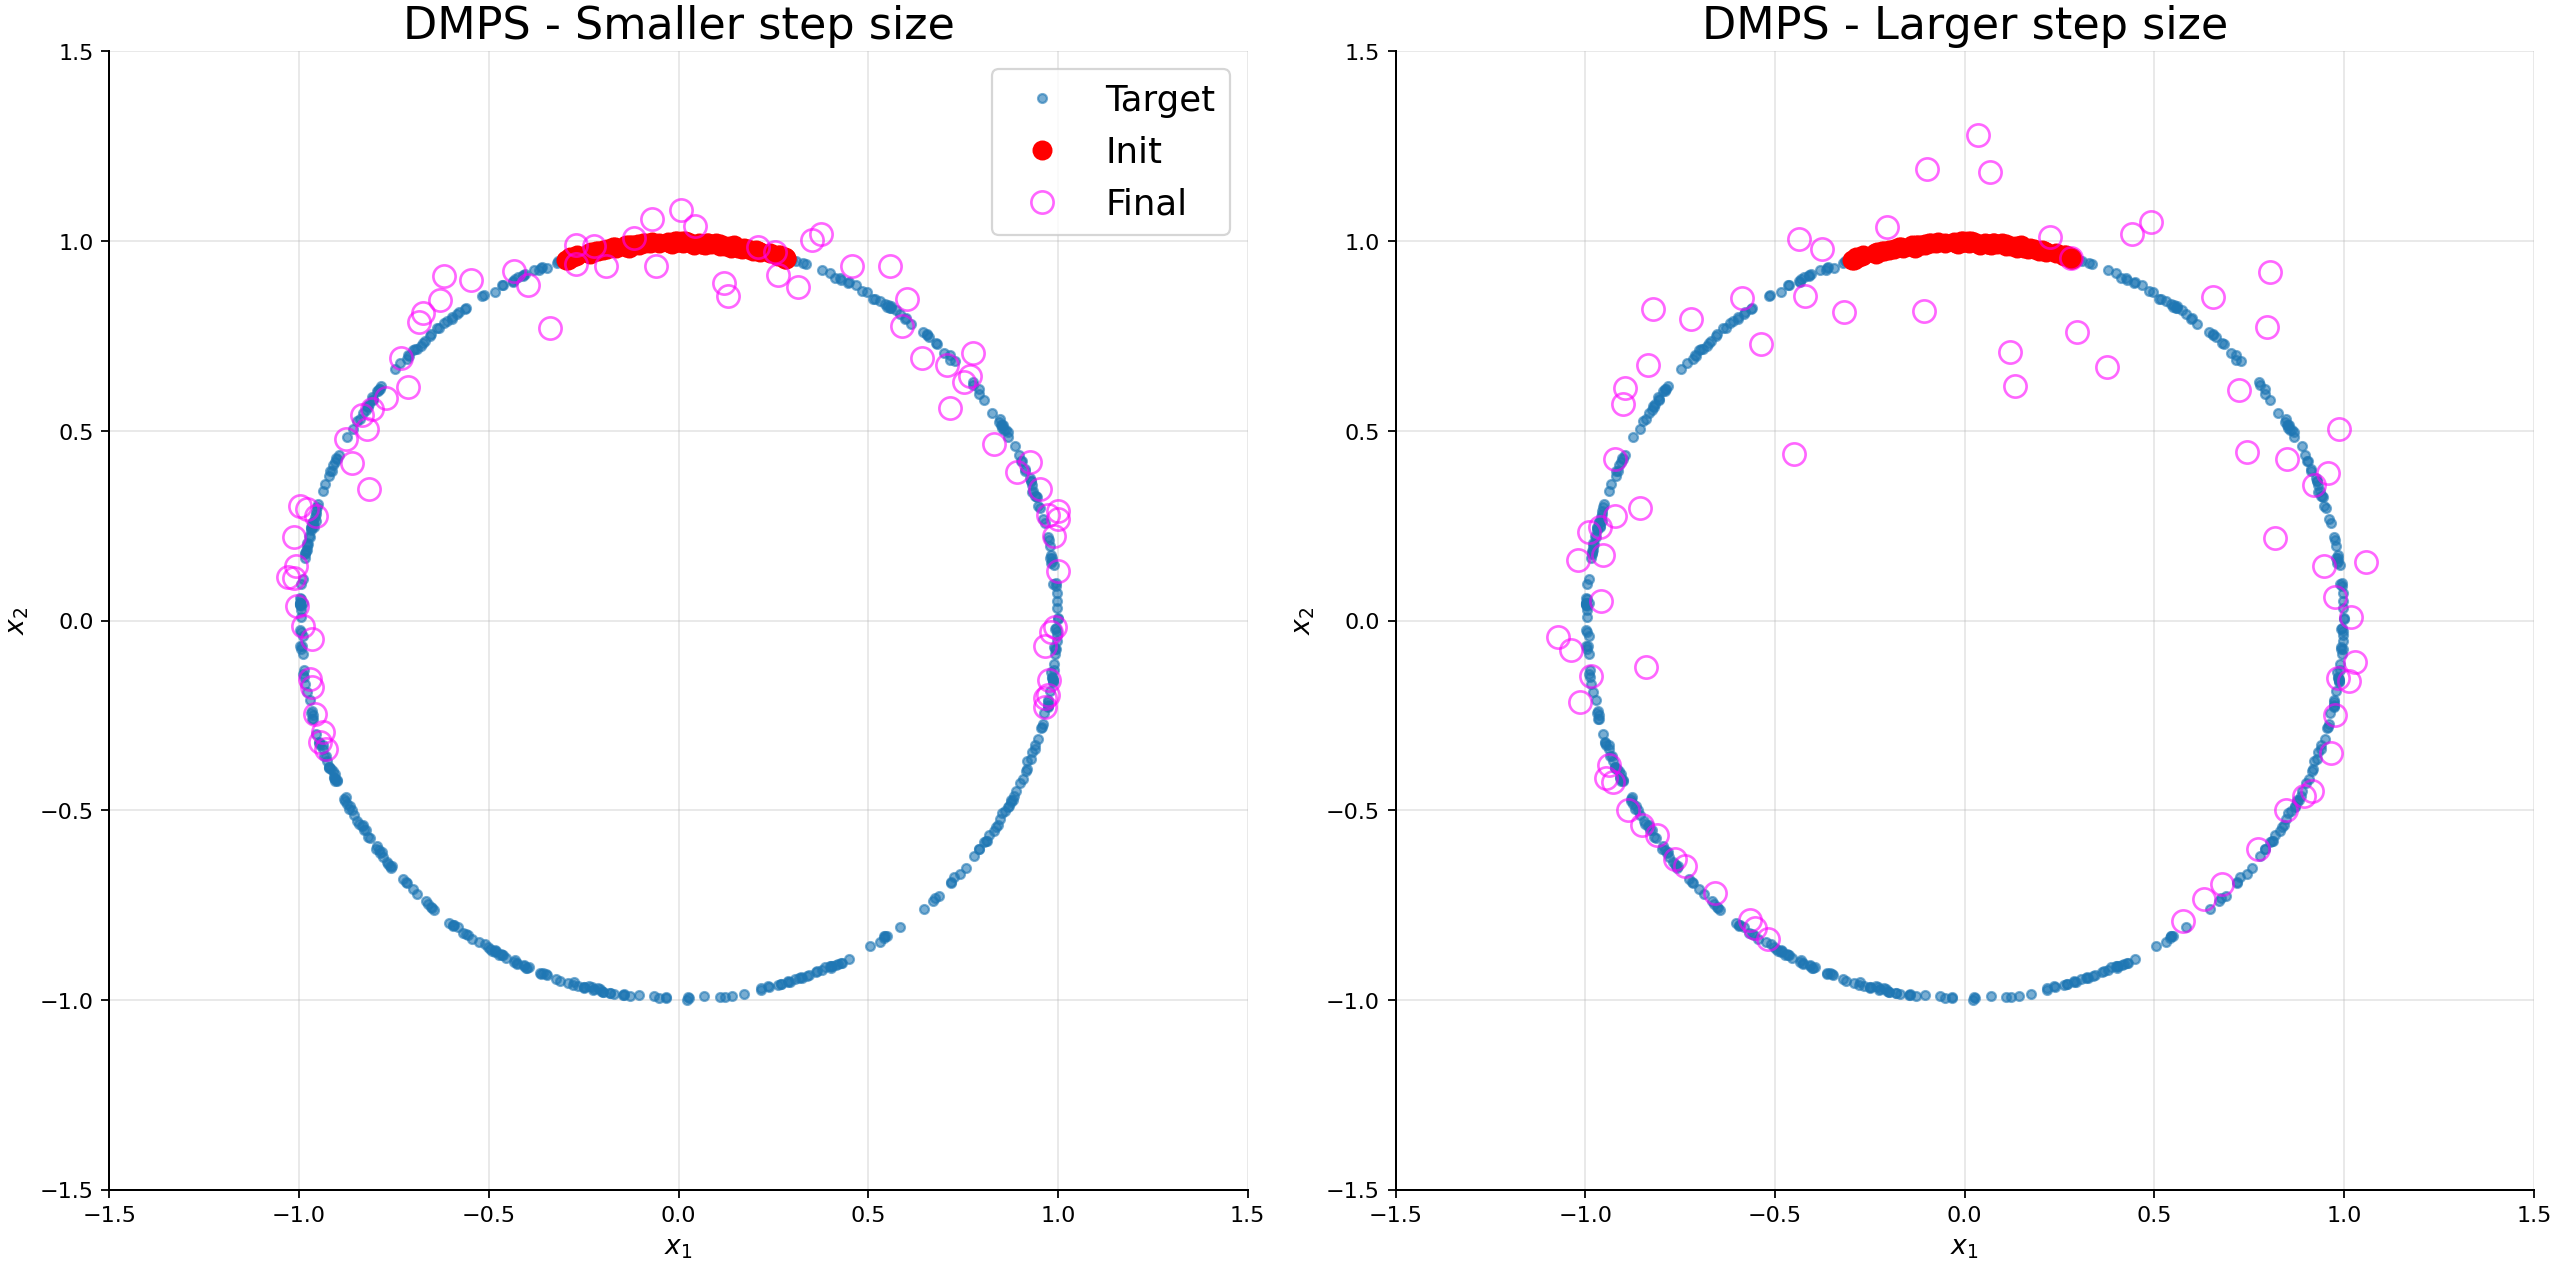

Step size (left/original): 2.0
Step size (right/larger): 4.0


In [11]:
# Plotting results
FIGSIZE_1X2 = (16, 8)
step_size_original = h
step_size_larger = 2 * h


def _compute_dmps_transport_for_plot(step_size, initial_positions):
    m_cmp = initial_positions.shape[0]
    x_cmp = np.zeros((m_cmp, d, iter), dtype=np.float64)
    x_cmp[:, :, 0] = initial_positions

    if USE_GPU:
        X_tar_gpu = cp.asarray(X_tar)
        p_tar_gpu = cp.asarray(p_tar)
        sq_tar_gpu = cp.asarray(sq_tar)
        D_gpu = cp.asarray(D)
        phi_gpu = cp.asarray(phi[:, :above_tol])
        lambda_ns_s_ns_gpu = cp.asarray(lambda_ns_s_ns)
        x_cmp_gpu = cp.asarray(x_cmp)
        diag_lambda_gpu = cp.diag(lambda_ns_s_ns_gpu)

        for t in range(iter - 1):
            x_slice = x_cmp_gpu[:, :, t]
            grad_matrix = grad_ker1(x_slice, X_tar_gpu, p_tar_gpu, sq_tar_gpu, D_gpu, epsilon)
            cross_matrix = K_tar_eval(X_tar_gpu, x_slice, p_tar_gpu, sq_tar_gpu, D_gpu, epsilon)

            sum_x_gpu = cp.zeros((m_cmp, d))
            for i in range(d):
                sum_x_gpu[:, i] = cp.sum(
                    grad_matrix[:, :, i] @ phi_gpu @ diag_lambda_gpu @ phi_gpu.T @ cross_matrix,
                    axis=1
                )

            x_cmp_gpu[:, :, t + 1] = x_slice - (step_size / m_cmp) * sum_x_gpu

        return cp.asnumpy(x_cmp_gpu)

    diag_lambda = np.diag(lambda_ns_s_ns)
    sum_x_cmp = np.zeros((m_cmp, d))
    for t in range(iter - 1):
        grad_matrix = grad_ker1(x_cmp[:, :, t], X_tar, p_tar, sq_tar, D, epsilon)
        cross_matrix = K_tar_eval(X_tar, x_cmp[:, :, t], p_tar, sq_tar, D, epsilon)
        for i in range(d):
            sum_x_cmp[:, i] = np.sum(
                grad_matrix[:, :, i] @ phi[:, :above_tol] @ diag_lambda @ phi[:, :above_tol].T @ cross_matrix,
                axis=1
            )
        x_cmp[:, :, t + 1] = x_cmp[:, :, t] - step_size / m_cmp * sum_x_cmp

    return x_cmp


x_init_for_compare = x_t[:, :, 0].copy()
x_t_larger_step = _compute_dmps_transport_for_plot(step_size_larger, x_init_for_compare)
plot_results = [('Smaller step size', x_t), ('Larger step size', x_t_larger_step)]

if d == 2:
    fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_1X2, constrained_layout=True)
    for idx, (ax, (title, x_plot)) in enumerate(zip(axes, plot_results)):
        ax.plot(X_tar[:, 0], X_tar[:, 1], 'o', markersize=4, alpha=0.6, label='Target')
        ax.plot(x_plot[:, 0, 0], x_plot[:, 1, 0], 'o', markersize=8, color='red', label='Init')
        ax.plot(x_plot[:, 0, -1], x_plot[:, 1, -1], 'o', markersize=10, markerfacecolor='none', markeredgecolor='magenta', markeredgewidth=1.2, alpha=0.6, label='Final')
        if idx == 0:
            ax.legend(fontsize=16, loc='upper right')
        ax.set_title(f'DMPS - {title}', fontsize=20)
        ax.set_xlabel('$x_1$')
        ax.set_ylabel('$x_2$')
        ax.set_aspect('equal', adjustable='box')
        ax.set_xlim(-1.5, 1.5)
        ax.set_ylim(-1.5, 1.5)
        ax.grid(True, alpha=0.3)
    plt.show()
else:
    from mpl_toolkits.mplot3d import Axes3D

    fig = plt.figure(figsize=FIGSIZE_1X2, constrained_layout=True)
    for idx, (title, x_plot) in enumerate(plot_results):
        ax = fig.add_subplot(1, 2, idx + 1, projection='3d')
        ax.scatter(X_tar[:, 0], X_tar[:, 1], X_tar[:, 2], s=20, alpha=0.6, label='Target')
        ax.scatter(x_plot[:, 0, 0], x_plot[:, 1, 0], x_plot[:, 2, 0], s=50, marker='o', color='red', label='Init')
        ax.scatter(x_plot[:, 0, -1], x_plot[:, 1, -1], x_plot[:, 2, -1], s=100, marker='o', facecolors='none', edgecolors='green', linewidths=0.8, alpha=0.5, label='Final')
        if idx == 0:
            ax.legend(fontsize=16, loc='upper right')
        ax.set_title(f'3D Results - DMPS - {title}', fontsize=20)
    plt.show()

print(f'Step size (left/original): {step_size_original}')
print(f'Step size (right/larger): {step_size_larger}')


## 10. Scatter Matrix Analysis

Multi-dimensional scatter matrix visualization of target distribution and final particle positions, with histograms on the diagonal.

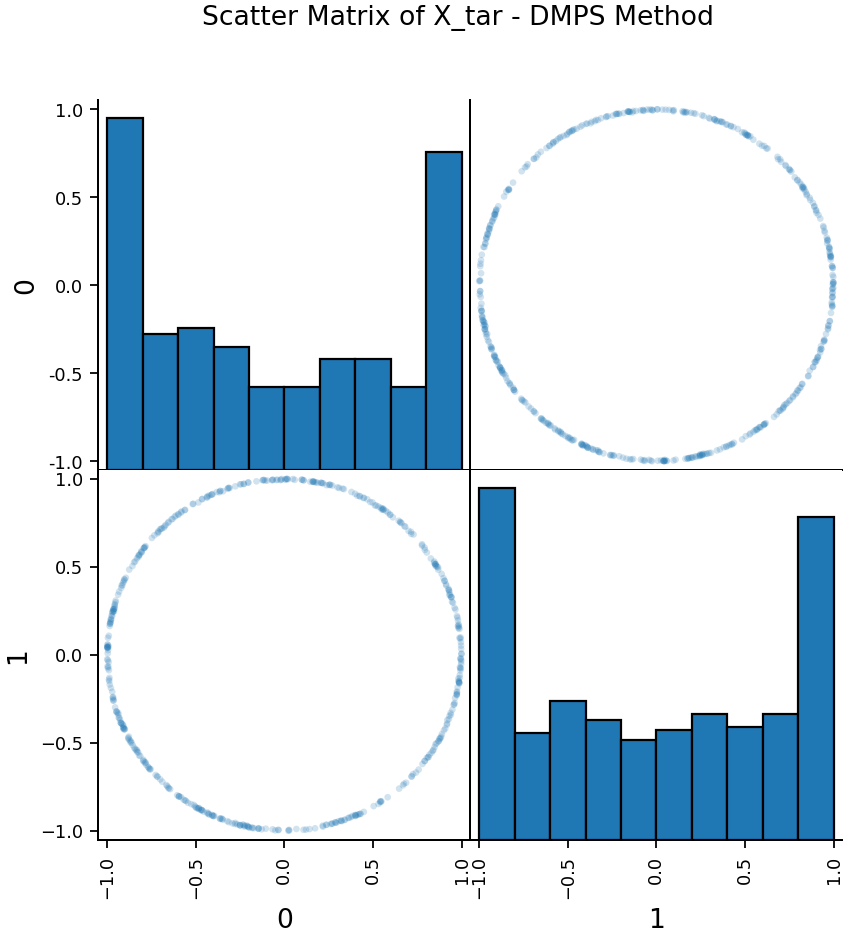

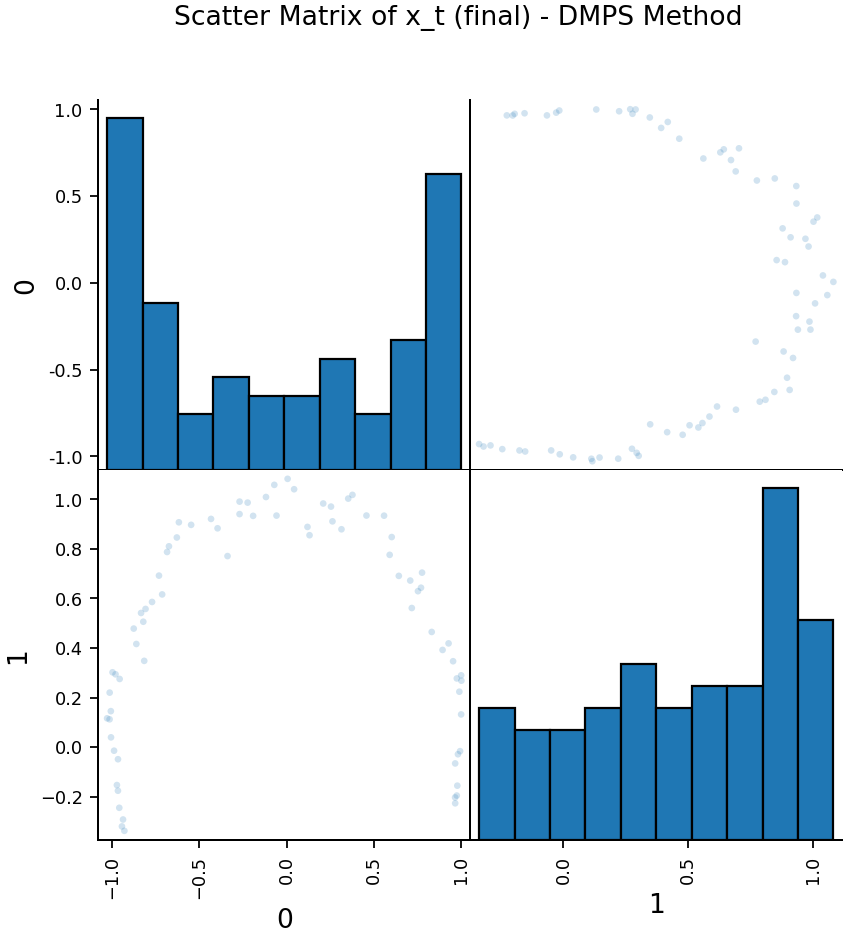

In [12]:
# Plot matrix (scatter matrix)
pd.plotting.scatter_matrix(
    pd.DataFrame(X_tar),
    alpha=0.2,
    figsize=(6, 6),
    diagonal='hist',
    hist_kwds={'edgecolor': 'black'}
)
plt.suptitle('Scatter Matrix of X_tar - DMPS Method')
plt.show()

pd.plotting.scatter_matrix(
    pd.DataFrame(x_t[:, :, -1]),
    alpha=0.2,
    figsize=(6, 6),
    diagonal='hist',
    hist_kwds={'edgecolor': 'black'}
)
plt.suptitle('Scatter Matrix of x_t (final) - DMPS Method')
plt.show()

## B. Kernel EDMD + KSWGD on Circle / Semi-Circle


## 1. Import Libraries and GPU/CPU Backend Configuration

In [13]:
import numpy as np
from scipy.linalg import svd, eigh
import matplotlib.pyplot as plt
import pandas as pd
import time

# --------------- Optional GPU backend (CuPy) ---------------
USE_GPU = True  # set False to force CPU even if CuPy is available
try:  # Attempt to import cupy
    import cupy as cp  # type: ignore
    GPU_AVAILABLE = True
except Exception:
    cp = None  # type: ignore
    GPU_AVAILABLE = False
USE_GPU = bool(USE_GPU and GPU_AVAILABLE)
if USE_GPU:
    from grad_ker1_gpu import grad_ker1  # xp-aware versions
    from K_tar_eval_gpu import K_tar_eval
else:
    from grad_ker1 import grad_ker1      # CPU fallbacks
    from K_tar_eval import K_tar_eval

print(f"[DEVICE] {'GPU' if USE_GPU else 'CPU'} mode active")

[DEVICE] GPU mode active


In [14]:
# --- Plot polish settings (visual only) ---
# This cell only controls figure appearance. It does not change sampling, kernels, spectra, or metrics.
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

PAPER_DPI = 160
EXPORT_DPI = 300

plt.rcParams.update({
    'figure.dpi': PAPER_DPI,
    'savefig.dpi': EXPORT_DPI,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.03,
    'font.family': 'DejaVu Sans',
    'mathtext.fontset': 'dejavusans',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'axes.linewidth': 0.9,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'image.interpolation': 'nearest',
})

def polish_axes(ax, *, equal=False, grid=False):
    """Apply consistent visual-only axis styling."""
    if equal:
        ax.set_aspect('equal', adjustable='box')
    ax.tick_params(direction='in', length=3, width=0.8)
    if grid:
        ax.grid(True, alpha=0.22, linestyle='--', linewidth=0.6)
    for spine in ax.spines.values():
        spine.set_linewidth(0.9)
        spine.set_color('0.25')
    return ax

def polish_legend(ax, **kwargs):
    """Draw a compact legend only when labelled artists exist."""
    handles, labels = ax.get_legend_handles_labels()
    labels = [label for label in labels if label and not label.startswith('_')]
    if labels:
        defaults = dict(frameon=True, framealpha=0.92, edgecolor='0.85')
        defaults.update(kwargs)
        return ax.legend(**defaults)
    return None

def set_pi_ticks(ax):
    ticks = [0, np.pi, 2 * np.pi]
    labels = ['0', r'$\pi$', r'$2\pi$']
    ax.set_xticks(ticks)
    ax.set_xticklabels(labels)
    ax.set_yticks(ticks)
    ax.set_yticklabels(labels)
    return ax


## 2. Define Timing and Progress Utility Functions

In [15]:
# ---------------- Timing / Progress Utilities ----------------
def _fmt_secs(s: float) -> str:
    s = max(0.0, float(s))
    h = int(s // 3600)
    m = int((s % 3600) // 60)
    sec = int(s % 60)
    if h > 0:
        return f"{h:02d}:{m:02d}:{sec:02d}"
    return f"{m:02d}:{sec:02d}"

def _print_phase(name: str, t_start: float) -> float:
    dt = time.time() - t_start
    print(f"[TIMER] {name}: {dt:.3f}s")
    return time.time()

_LAST_PROGRESS_LEN = 0
def _print_progress(curr: int, total: int, start_time: float, prefix: str = "") -> None:
    global _LAST_PROGRESS_LEN
    total = max(1, int(total))
    curr = min(max(0, curr), total)
    bar_len = 30
    filled = int(bar_len * curr / total)
    filled = min(filled, bar_len)
    bar = ("=" * filled) + (">" if filled < bar_len else "") + ("." * max(0, bar_len - filled - (0 if filled == bar_len else 1)))
    pct = 100.0 * curr / total
    elapsed = time.time() - start_time
    avg = elapsed / max(1, curr)
    eta = avg * (total - curr)
    msg = f"{prefix}[{bar}] {pct:5.1f}% | iter {curr}/{total} | elapsed {_fmt_secs(elapsed)} | eta {_fmt_secs(eta)}"
    prev = _LAST_PROGRESS_LEN
    clear = "\r" + (" " * prev) + "\r"
    print(clear, end="")
    print(msg, end="", flush=True)
    _LAST_PROGRESS_LEN = len(msg)

# Set random seed for reproducibility
np.random.seed(0)
_t = time.time()

## 3. Configuration Parameters

- `USE_SEMICIRCLE`: True for semi-circle, False for full circle
- `KERNEL_TYPE`: Kernel selection (1: RBF, 2: Spherical, 3: Matérn, 4: Rational Quadratic, 5: Polynomial)
- `n`: Number of target sample points (500)
- `d`: Dimensions (2D)
- `lambda_`: Anisotropy parameter (1 means isotropic)

In [16]:
# ---------------- Configuration ----------------
USE_SEMICIRCLE = bool(globals().get('USE_SEMICIRCLE', False))  # False: full circle; True: upper semi-circle
KERNEL_TYPE = int(globals().get('SPHERE_KERNEL_TYPE', 5))  # 1: RBF, 2: Spherical, 3: Matern, 4: Rational Quadratic, 5: Polynomial

# Sample 500 points from a circle or semi-circle
n = int(globals().get('SPHERE_N_TARGET', 500))
d = int(globals().get('SPHERE_DIM', 2))
lambda_ = float(globals().get('SPHERE_ANISOTROPY', 1.0))  # 1.0 is isotropic

## 4. Generate Target Distribution Samples (X_tar)

Using rejection sampling for semi-circle or Gaussian sampling for full circle.

In [17]:
if USE_SEMICIRCLE:
    # Rejection Sampling for semi-circle
    samples = []
    while len(samples) < n:
        batch_size = max(n - len(samples), int((n - len(samples)) * 2.5))
        u = np.random.normal(0, 1, (batch_size, d))
        u[:, 0] = lambda_ * u[:, 0]  # Apply anisotropy
        u_norm = np.linalg.norm(u, axis=1, keepdims=True)
        u_trans = u / (u_norm + 1e-12)
        valid = u_trans[:, 1] >= 0  # Filter for y >= 0
        samples.append(u_trans[valid, :])
    u_trans = np.vstack(samples)[:n, :]
    label = "semi-circle"
else:
    # Gaussian Sampling for full circle
    u = np.random.normal(0, 1, (n, d))
    u[:, 0] = lambda_ * u[:, 0]
    u_norm = np.linalg.norm(u, axis=1, keepdims=True)
    u_trans = u / (u_norm + 1e-12)
    label = "full circle"

# Radial distance: slightly randomized around radius 1
r = np.sqrt(np.random.rand(n, 1)) * 1/100 + 99/100
X_tar = r * u_trans
n = X_tar.shape[0]
print(f"Generated {n} points on {label}")

Generated 500 points on full circle


## 5. Kernel EDMD: Generate X_tar_next via Manifold Langevin Dynamics

**Key Steps:**
1. KDE-based score estimation (drift term): $\nabla \log \pi(x)$
2. Project score to tangent space (manifold constraint)
3. **Itô SDE with Stratonovich correction**: Add explicit correction term $-(d-1)x \cdot dt$
4. Langevin update with tangent-projected noise
5. Renormalize to stay on the sphere (numerical stability only)
6. Apply reflecting boundary for semi-circle

**Mathematical Background (Itô-Stratonovich Conversion):**
- Stratonovich SDE: $dX = b(X) \circ dt + \sigma \circ dW$ respects chain rule on manifolds
- Equivalent Itô SDE: $dX = [b(X) + \text{correction}] dt + \sigma dW$
- For sphere $S^{d-1}$: correction $= -(d-1) \cdot x$ (mean curvature direction)
- This is the "noise-induced drift" or "Wong-Zakai correction"

In [18]:
# Step 1: KDE-based score estimation (drift term)
dt_edmd = 5e-2  # Sampling time
diffs_edmd = X_tar[:, None, :] - X_tar[None, :, :]
dist2_edmd = np.sum(diffs_edmd ** 2, axis=2)
h_edmd = np.sqrt(np.median(dist2_edmd) + 1e-12)
W_edmd = np.exp(-dist2_edmd / (2.0 * (h_edmd ** 2)))
sumW_edmd = np.sum(W_edmd, axis=1, keepdims=True) + 1e-12
weighted_means_edmd = (W_edmd @ X_tar) / sumW_edmd
score_eucl = (weighted_means_edmd - X_tar) / (h_edmd ** 2)

# Step 2: Project score to tangent space
X_norm = X_tar / (np.linalg.norm(X_tar, axis=1, keepdims=True) + 1e-12)
proj = np.eye(X_tar.shape[1])[None, :, :] - X_norm[:, :, None] * X_norm[:, None, :]
score_tan = np.einsum('nij,ni->nj', proj, score_eucl)

# Step 3: Itô-Stratonovich correction term
# For sphere S^{d-1}, the correction is -(d-1)*x pointing toward the center
# This compensates for the spatial variation of the projection operator P(x) = I - xx^T
ito_stratonovich_correction = -(d - 1) * X_norm  # Normal direction, magnitude = mean curvature

# Step 4: Langevin update with tangent-projected noise
noise_multiplier = 3.0  # Amplify noise for better boundary exploration
xi_edmd = np.random.normal(0.0, 1.0, size=X_tar.shape)
xi_tan = xi_edmd - (np.sum(X_norm * xi_edmd, axis=1, keepdims=True)) * X_norm

# Full Itô update: drift (score) + Stratonovich correction + diffusion
# Equivalent to Stratonovich: dX = score_tan ∘ dt + √2 ∘ dW_tan
X_step = (X_norm 
          + dt_edmd * score_tan                              # Tangent drift (score)
          + dt_edmd * ito_stratonovich_correction            # Stratonovich correction (normal)
          + noise_multiplier * np.sqrt(2.0 * dt_edmd) * xi_tan)  # Tangent diffusion

# Step 5: Renormalize to stay on the sphere (numerical stability, not geometric correction)
X_tar_next = X_step / (np.linalg.norm(X_step, axis=1, keepdims=True) + 1e-12)

# Step 5: Apply reflecting boundary for semi-circle
if USE_SEMICIRCLE:
    crossed_boundary = X_tar_next[:, 1] < 0
    num_crossed = np.sum(crossed_boundary)
    
    if num_crossed > 0:
        X_tar_next[crossed_boundary, 1] = -X_tar_next[crossed_boundary, 1]
        print(f"[BOUNDARY FIX] Applied reflection to {num_crossed}/{n} points ({100*num_crossed/n:.1f}%)")
        print(f"[BOUNDARY INFO] This teaches Koopman operator about boundary dynamics!")
    else:
        print(f"[BOUNDARY WARNING] No particles crossed boundary!")
        print(f"[BOUNDARY HINT] Consider increasing dt_edmd or noise_multiplier")

# Verify X_tar_next is strictly on semi-circle
if USE_SEMICIRCLE:
    min_y = np.min(X_tar_next[:, 1])
    if min_y < -1e-10:
        print(f"[WARNING] X_tar_next has points below y=0! min_y = {min_y:.6e}")
    else:
        print(f"[VERIFIED] X_tar_next strictly on semi-circle (min_y = {min_y:.6e})")

## 6. Visualize Time Evolution Pair (X_tar vs X_tar_next)

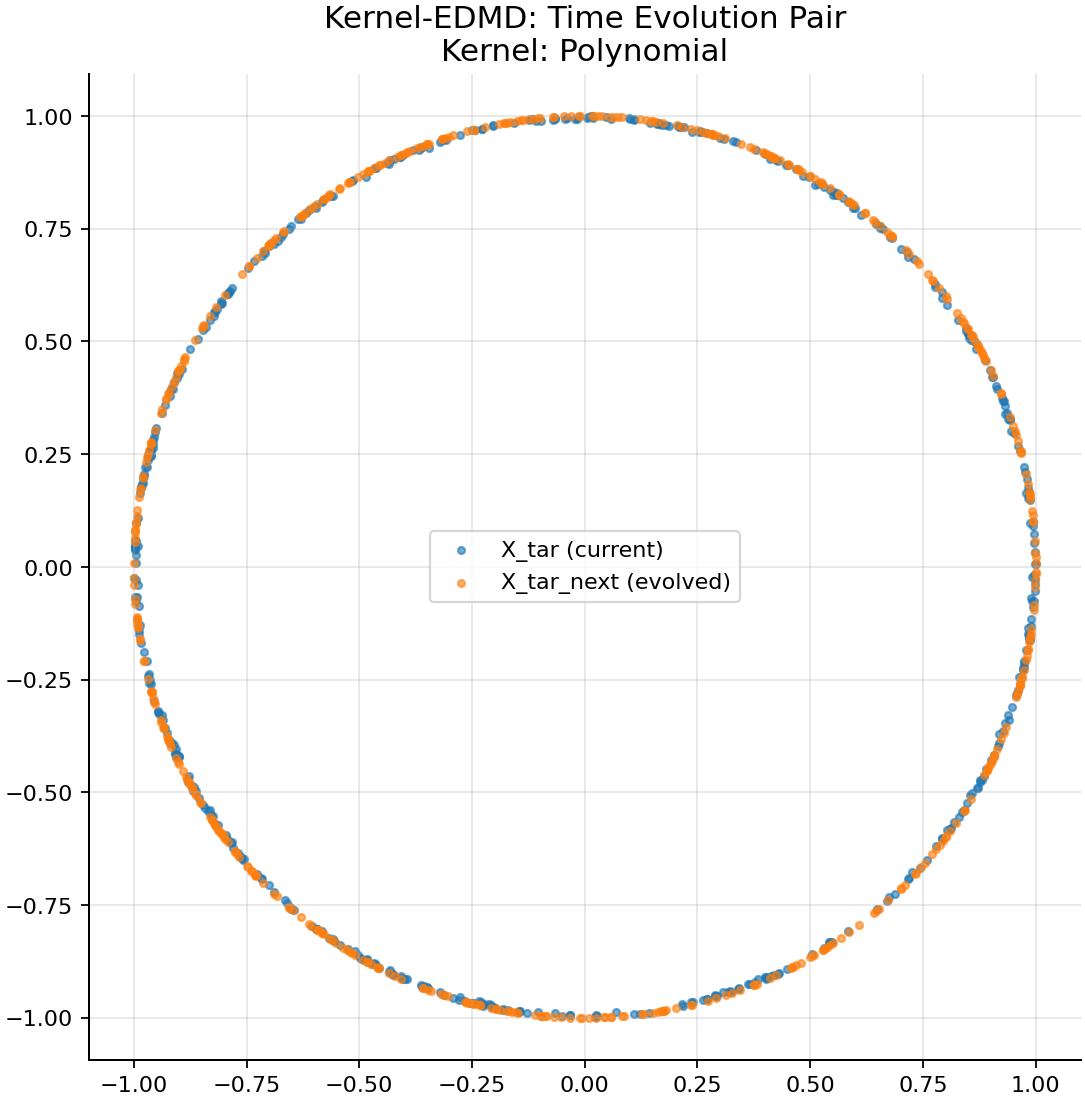

In [19]:
kernel_names = {1: "RBF", 2: "Spherical", 3: "Matern", 4: "Rational Quadratic", 5: "Polynomial"}
kernel_display = kernel_names.get(KERNEL_TYPE, "Unknown")

if d == 2:
    plt.figure(figsize=(8, 8))
    plt.scatter(X_tar[:, 0], X_tar[:, 1], s=10, c='C0', alpha=0.6, label='X_tar (current)')
    plt.scatter(X_tar_next[:, 0], X_tar_next[:, 1], s=10, c='C1', alpha=0.6, label='X_tar_next (evolved)')
    plt.legend()
    plt.axis('equal')
    plt.title(f'Kernel-EDMD: Time Evolution Pair\nKernel: {kernel_display}')
    plt.grid(True, alpha=0.3)
    plt.show()

## 7. Define Kernel Functions

Five kernel options available:
1. **RBF/Gaussian**: $k(x,y) = \exp(-\|x-y\|^2/(2\varepsilon))$
2. **Spherical**: $k(x,y) = \exp(-d_{\text{geodesic}}^2/(2\theta^2))$ - Respects manifold geometry
3. **Matérn**: $k(x,y) = (1 + \sqrt{3} \cdot d/\ell) \cdot \exp(-\sqrt{3} \cdot d/\ell)$ - Controls smoothness
4. **Rational Quadratic**: $k(x,y) = (1 + \|x-y\|^2/(2\alpha \cdot \ell^2))^{-\alpha}$ - Multi-scale features
5. **Polynomial**: $k(x,y) = (\gamma \cdot \langle x,y \rangle + c_0)^d$ - Efficient, captures polynomial structure

In [20]:
def kernel1_rbf(X, Y, eps):
    """RBF/Gaussian Kernel"""
    sq_x = np.sum(X ** 2, axis=1)
    sq_y = np.sum(Y ** 2, axis=1)
    D2 = sq_x[:, None] + sq_y[None, :] - 2 * (X @ Y.T)
    return np.exp(-D2 / (2 * eps))

def kernel2_spherical(X, Y, theta_scale=1.0):
    """Spherical/Geodesic Kernel"""
    X_norm = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)
    Y_norm = Y / (np.linalg.norm(Y, axis=1, keepdims=True) + 1e-12)
    cos_sim = X_norm @ Y_norm.T
    cos_sim = np.clip(cos_sim, -1.0, 1.0)
    geodesic_dist = np.arccos(cos_sim)
    return np.exp(-geodesic_dist**2 / (2 * theta_scale**2))

def kernel3_matern(X, Y, length_scale=1.0, nu=1.5):
    """Matern Kernel (nu=1.5)"""
    sq_x = np.sum(X ** 2, axis=1)
    sq_y = np.sum(Y ** 2, axis=1)
    D2 = sq_x[:, None] + sq_y[None, :] - 2 * (X @ Y.T)
    D = np.sqrt(np.maximum(D2, 0))
    sqrt3_D = np.sqrt(3) * D / length_scale
    return (1 + sqrt3_D) * np.exp(-sqrt3_D)

def kernel4_rational_quadratic(X, Y, alpha=1.0, length_scale=1.0):
    """Rational Quadratic Kernel"""
    sq_x = np.sum(X ** 2, axis=1)
    sq_y = np.sum(Y ** 2, axis=1)
    D2 = sq_x[:, None] + sq_y[None, :] - 2 * (X @ Y.T)
    return (1 + D2 / (2 * alpha * length_scale**2)) ** (-alpha)

def kernel5_polynomial(X, Y, degree=3, coef0=1.0, gamma=None):
    """Polynomial Kernel"""
    if gamma is None:
        gamma = 1.0 / X.shape[1]
    inner_prod = X @ Y.T
    return (gamma * inner_prod + coef0) ** degree

## 8. Compute Kernel Matrices (K_xx and K_xy)

**Critical**: K_xy is computed AFTER reflection boundary fix on X_tar_next!

In [21]:
# Compute bandwidth parameter
sq_tar = np.sum(X_tar ** 2, axis=1)
H = sq_tar[:, None] + sq_tar[None, :] - 2 * (X_tar @ X_tar.T)
epsilon = 0.5 * np.median(H) / (np.log(n + 1) + 1e-12)
length_scale = np.sqrt(np.median(H))

# Select and apply kernel
if KERNEL_TYPE == 1:
    kernel_name = "RBF"
    K_xx = kernel1_rbf(X_tar, X_tar, epsilon)
    K_xy = kernel1_rbf(X_tar, X_tar_next, epsilon)
elif KERNEL_TYPE == 2:
    kernel_name = "Spherical"
    theta_scale = 0.3
    K_xx = kernel2_spherical(X_tar, X_tar, theta_scale=theta_scale)
    K_xy = kernel2_spherical(X_tar, X_tar_next, theta_scale=theta_scale)
elif KERNEL_TYPE == 3:
    kernel_name = "Matern"
    K_xx = kernel3_matern(X_tar, X_tar, length_scale=length_scale, nu=1.5)
    K_xy = kernel3_matern(X_tar, X_tar_next, length_scale=length_scale, nu=1.5)
elif KERNEL_TYPE == 4:
    kernel_name = "Rational Quadratic"
    alpha = 2.0
    K_xx = kernel4_rational_quadratic(X_tar, X_tar, alpha=alpha, length_scale=length_scale)
    K_xy = kernel4_rational_quadratic(X_tar, X_tar_next, alpha=alpha, length_scale=length_scale)
elif KERNEL_TYPE == 5:
    kernel_name = "Polynomial"
    poly_degree = 10
    poly_coef0 = 1.0
    poly_gamma = 1.0 / d
    K_xx = kernel5_polynomial(X_tar, X_tar, degree=poly_degree, coef0=poly_coef0, gamma=poly_gamma)
    K_xy = kernel5_polynomial(X_tar, X_tar_next, degree=poly_degree, coef0=poly_coef0, gamma=poly_gamma)
else:
    raise ValueError(f"Invalid KERNEL_TYPE: {KERNEL_TYPE}")

print(f"[KERNEL] Using {kernel_name} kernel (Type {KERNEL_TYPE})")
_t = _print_phase(f"Kernel-EDMD: Gram matrices K_xx and K_xy ({kernel_name})", _t)

[KERNEL] Using Polynomial kernel (Type 5)
[TIMER] Kernel-EDMD: Gram matrices K_xx and K_xy (Polynomial): 0.284s


## 9. Compute Koopman Operator via Kernel EDMD

**Formula**: $K_{\text{koopman}} = K_{xy} (K_{xx} + \gamma I)^{-1}$

This approximates the Koopman operator for the dynamics $X_t \to X_{t+dt}$

In [22]:
gamma_ridge = 1e-6  # Tikhonov regularization parameter (\gamma)

# Use eigendecomposition for stable inversion
evals_kxx, Q_kxx = eigh(K_xx)
evals_kxx = np.clip(evals_kxx, 0.0, None)
inv_evals = 1.0 / (evals_kxx + gamma_ridge)
data_kernel = K_xy @ (Q_kxx @ (np.diag(inv_evals) @ Q_kxx.T))

# Safety: ensure finite values
data_kernel = np.nan_to_num(data_kernel, nan=0.0, posinf=0.0, neginf=0.0)
minK = float(np.min(data_kernel))
if minK < 0.0:
    data_kernel = data_kernel - minK + 1e-12
_t = _print_phase(r"Kernel-EDMD: Koopman operator $K_{xy} (K_{xx} + \gamma I)^{-1}$", _t)


[TIMER] Kernel-EDMD: Koopman operator $K_{xy} (K_{xx} + \gamma I)^{-1}$: 0.155s


## 10. DMPS-Style Normalization

Apply density normalization and random-walk symmetric normalization to the Koopman operator.

In [23]:
sq_tar = np.sum(X_tar ** 2, axis=1)  # Keep for downstream gradient computations

p_x = np.sqrt(np.sum(data_kernel, axis=1))
p_y = p_x.copy()
data_kernel_norm = data_kernel / p_x[:, None] / p_y[None, :]
D_y = np.sum(data_kernel_norm, axis=0)

rw_kernel = 0.5 * (data_kernel_norm / D_y + data_kernel_norm / D_y[:, None])

## 11. Spectral Decomposition (Eigendecomposition)

Using `eigh` for symmetric matrices (faster than SVD).

In [24]:
# Eigendecomposition (returns ascending order, need to reverse)
evals_rw, evecs_rw = eigh(rw_kernel)
phi = evecs_rw[:, ::-1]  # Reverse to descending order
s = evals_rw[::-1]

# Truncate eigenvalues below threshold
tol_truncate = 1e-6
s_original = s.copy()
s = np.where(s < tol_truncate, 0.0, s)
num_truncated = np.sum(s_original < tol_truncate)
print(f"[INFO] Truncated {num_truncated} eigenvalues < {tol_truncate:.0e} to zero")
_t = _print_phase("Eigendecomposition on rw_kernel", _t)

lambda_ns = s

[INFO] Truncated 255 eigenvalues < 1e-06 to zero


[TIMER] Eigendecomposition on rw_kernel: 0.291s


## 12. Eigenvalue Analysis

In [25]:
print("\n[EIGENVALUE ANALYSIS]")
print(f"Total eigenvalues: {len(lambda_ns)}")
print(f"Largest eigenvalue: {lambda_ns[0]:.6f}")
print(f"Smallest eigenvalue (after clipping): {lambda_ns[-1]:.6e}")

count_gt_1 = np.sum(lambda_ns > 1.0)
print(f"Eigenvalues > 1.0: {count_gt_1}")

count_lt_0 = np.sum(lambda_ns < 0.0)
print(f"Eigenvalues < 0.0 (after clipping): {count_lt_0}")

tol_small = 1e-6
count_near_0 = np.sum((lambda_ns >= 0.0) & (lambda_ns < tol_small))
print(f"Eigenvalues in [0, {tol_small:.0e}): {count_near_0}")

count_tiny_to_1 = np.sum((lambda_ns >= tol_small) & (lambda_ns <= 1.0))
print(f"Eigenvalues in [{tol_small:.0e}, 1.0]: {count_tiny_to_1}")

print(f"\nFirst 10 eigenvalues:")
for i in range(min(10, len(lambda_ns))):
    print(f"  lambda[{i}] = {lambda_ns[i]:.8f}")
print("=" * 60 + "\n")


[EIGENVALUE ANALYSIS]
Total eigenvalues: 500
Largest eigenvalue: 1.000168
Smallest eigenvalue (after clipping): 0.000000e+00
Eigenvalues > 1.0: 1
Eigenvalues < 0.0 (after clipping): 0
Eigenvalues in [0, 1e-06): 255
Eigenvalues in [1e-06, 1.0]: 244

First 10 eigenvalues:
  lambda[0] = 1.00016802
  lambda[1] = 0.11363541
  lambda[2] = 0.10574427
  lambda[3] = 0.09412779
  lambda[4] = 0.08986564
  lambda[5] = 0.05150953
  lambda[6] = 0.04931718
  lambda[7] = 0.03905155
  lambda[8] = 0.03385729
  lambda[9] = 0.03306788



## 13. Compute Inverse Weights for Gradient Calculations

In [26]:
lambda_ = -lambda_ns + 1
inv_lambda = np.zeros_like(lambda_)
inv_lambda[1:] = 1 / lambda_[1:]
inv_lambda = inv_lambda * epsilon
inv_K = phi @ np.diag(inv_lambda) @ phi.T

tol = 1e-6
lambda_ns_mod = np.copy(lambda_ns)
lambda_ns_mod[lambda_ns_mod < tol] = 0
below_tol = np.sum(lambda_ns < tol)
above_tol = n - below_tol
reg = 0.001
lambda_ns_inv = np.zeros_like(lambda_ns)
mask = lambda_ns >= tol
lambda_ns_inv[mask] = epsilon / (lambda_ns[mask] + reg)
inv_K_ns = phi @ np.diag(lambda_ns_inv) @ phi.T

## 14. Particle Initialization

Initialize particles based on mode (full circle or semi-circle).

In [27]:
iter = int(globals().get('SPHERE_NUM_ITER', 1000))
h = float(globals().get('SPHERE_STEP_SIZE', 2.0))
m = int(globals().get('SPHERE_INIT_PARTICLES', 700))
u = np.random.normal(0, 1, (m, d))
u_norm = np.linalg.norm(u, axis=1, keepdims=True)
r = np.sqrt(np.random.rand(m, 1)) * 1/100 + 99/100
u_trans = u / u_norm
x_init = r * u_trans

if USE_SEMICIRCLE:
    x_init = x_init[x_init[:, 1] > 0.9, :]
else:
    x_init = x_init[x_init[:, 1] > 0.95, :]

m = x_init.shape[0]
print(f"[INFO] Initialized {m} particles ({'semi-circle' if USE_SEMICIRCLE else 'full circle'} mode)")
x_t = np.zeros((m, d, iter), dtype=np.float64)
x_t[:, :, 0] = x_init

p_tar = np.sum(data_kernel, axis=0)
D = np.sum(data_kernel / np.sqrt(p_tar) / np.sqrt(p_tar)[:, None], axis=1)

inv_K_ns_s_ns = phi @ np.diag(lambda_ns_inv * inv_lambda * lambda_ns_inv) @ phi.T
lambda_s_s_ns = inv_lambda * inv_lambda * lambda_ns_inv
lambda_s_s_ns = lambda_s_s_ns[:above_tol]
lambda_ns_s_ns = lambda_ns_inv * inv_lambda * lambda_ns_inv
lambda_ns_s_ns = lambda_ns_s_ns[:above_tol]

sum_x = np.zeros((m, d))

[INFO] Initialized 78 particles (full circle mode)


## 15. KSWGD Iteration Loop

**Data-driven learning**: NO artificial boundary operations!

The Koopman operator should have learned the boundary behavior from the training data.

In [28]:
loop_start = time.time()
total_loop = iter - 1

if USE_GPU:
    # Stage constants on GPU
    X_tar_gpu = cp.asarray(X_tar)
    p_tar_gpu = cp.asarray(p_tar)
    sq_tar_gpu = cp.asarray(sq_tar)
    D_gpu = cp.asarray(D)
    phi_gpu = cp.asarray(phi[:, :above_tol])
    lambda_ns_s_ns_gpu = cp.asarray(lambda_ns_s_ns)
    x_t_gpu = cp.asarray(x_t)
    diag_lambda_gpu = cp.diag(lambda_ns_s_ns_gpu)
    
    # Iteration loop (GPU)
    for t in range(iter - 1):
        x_slice = x_t_gpu[:, :, t]
        grad_matrix = grad_ker1(x_slice, X_tar_gpu, p_tar_gpu, sq_tar_gpu, D_gpu, epsilon)
        cross_matrix = K_tar_eval(X_tar_gpu, x_slice, p_tar_gpu, sq_tar_gpu, D_gpu, epsilon)
        
        sum_x_gpu = cp.zeros((m, d))
        for i in range(d):
            sum_x_gpu[:, i] = cp.sum(
                grad_matrix[:, :, i] @ phi_gpu @ diag_lambda_gpu @ phi_gpu.T @ cross_matrix,
                axis=1
            )
        
        x_proposed = x_slice - (h / m) * sum_x_gpu
        x_norm_proposed = cp.sqrt(cp.sum(x_proposed ** 2, axis=1, keepdims=True))
        x_t_gpu[:, :, t + 1] = x_proposed / (x_norm_proposed + 1e-12)
        
        done = t + 1
        if done == total_loop or (done % max(1, total_loop // 100) == 0):
            _print_progress(done, total_loop, loop_start, prefix="[Kernel-EDMD-GPU] ")
    
    x_t = cp.asnumpy(x_t_gpu)
else:
    # CPU iteration loop
    for t in range(iter - 1):
        grad_matrix = grad_ker1(x_t[:, :, t], X_tar, p_tar, sq_tar, D, epsilon)
        cross_matrix = K_tar_eval(X_tar, x_t[:, :, t], p_tar, sq_tar, D, epsilon)
        for i in range(d):
            sum_x[:, i] = np.sum(
                grad_matrix[:, :, i] @ phi[:, :above_tol] @ np.diag(lambda_ns_s_ns) @ phi[:, :above_tol].T @ cross_matrix,
                axis=1
            )
        
        x_proposed = x_t[:, :, t] - h / m * sum_x
        x_norm_proposed = np.sqrt(np.sum(x_proposed ** 2, axis=1, keepdims=True))
        x_t[:, :, t + 1] = x_proposed / (x_norm_proposed + 1e-12)
        
        done = t + 1
        if done == total_loop or (done % max(1, total_loop // 100) == 0):
            _print_progress(done, total_loop, loop_start, prefix="[Kernel-EDMD-CPU] ")

print()
_t = _print_phase("Iteration loop total", loop_start)

[Kernel-EDMD-GPU] [>.............................]   0.9% | iter 9/999 | elapsed 00:00 | eta 00:09

[Kernel-EDMD-GPU] [>.............................]   1.8% | iter 18/999 | elapsed 00:00 | eta 00:05

[Kernel-EDMD-GPU] [>.............................]   2.7% | iter 27/999 | elapsed 00:00 | eta 00:04

[Kernel-EDMD-GPU] [=>............................]   3.6% | iter 36/999 | elapsed 00:00 | eta 00:03

[Kernel-EDMD-GPU] [=>............................]   4.5% | iter 45/999 | elapsed 00:00 | eta 00:03

...

[Kernel-EDMD-GPU] [=============================>]  97.3% | iter 972/999 | elapsed 00:01 | eta 00:00

[Kernel-EDMD-GPU] [=============================>]  98.2% | iter 981/999 | elapsed 00:01 | eta 00:00

[Kernel-EDMD-GPU] [=============================>]  99.1% | iter 990/999 | elapsed 00:01 | eta 00:00

[Kernel-EDMD-GPU] [==============================] 100.0% | iter 999/999 | elapsed 00:01 | eta 00:00


[TIMER] Iteration loop total: 1.895s


## 16. Visualize Results (2D/3D)

- **Blue dots**: Target distribution
- **Red solid circles**: Initial particle positions
- **Magenta hollow circles**: Final particle positions

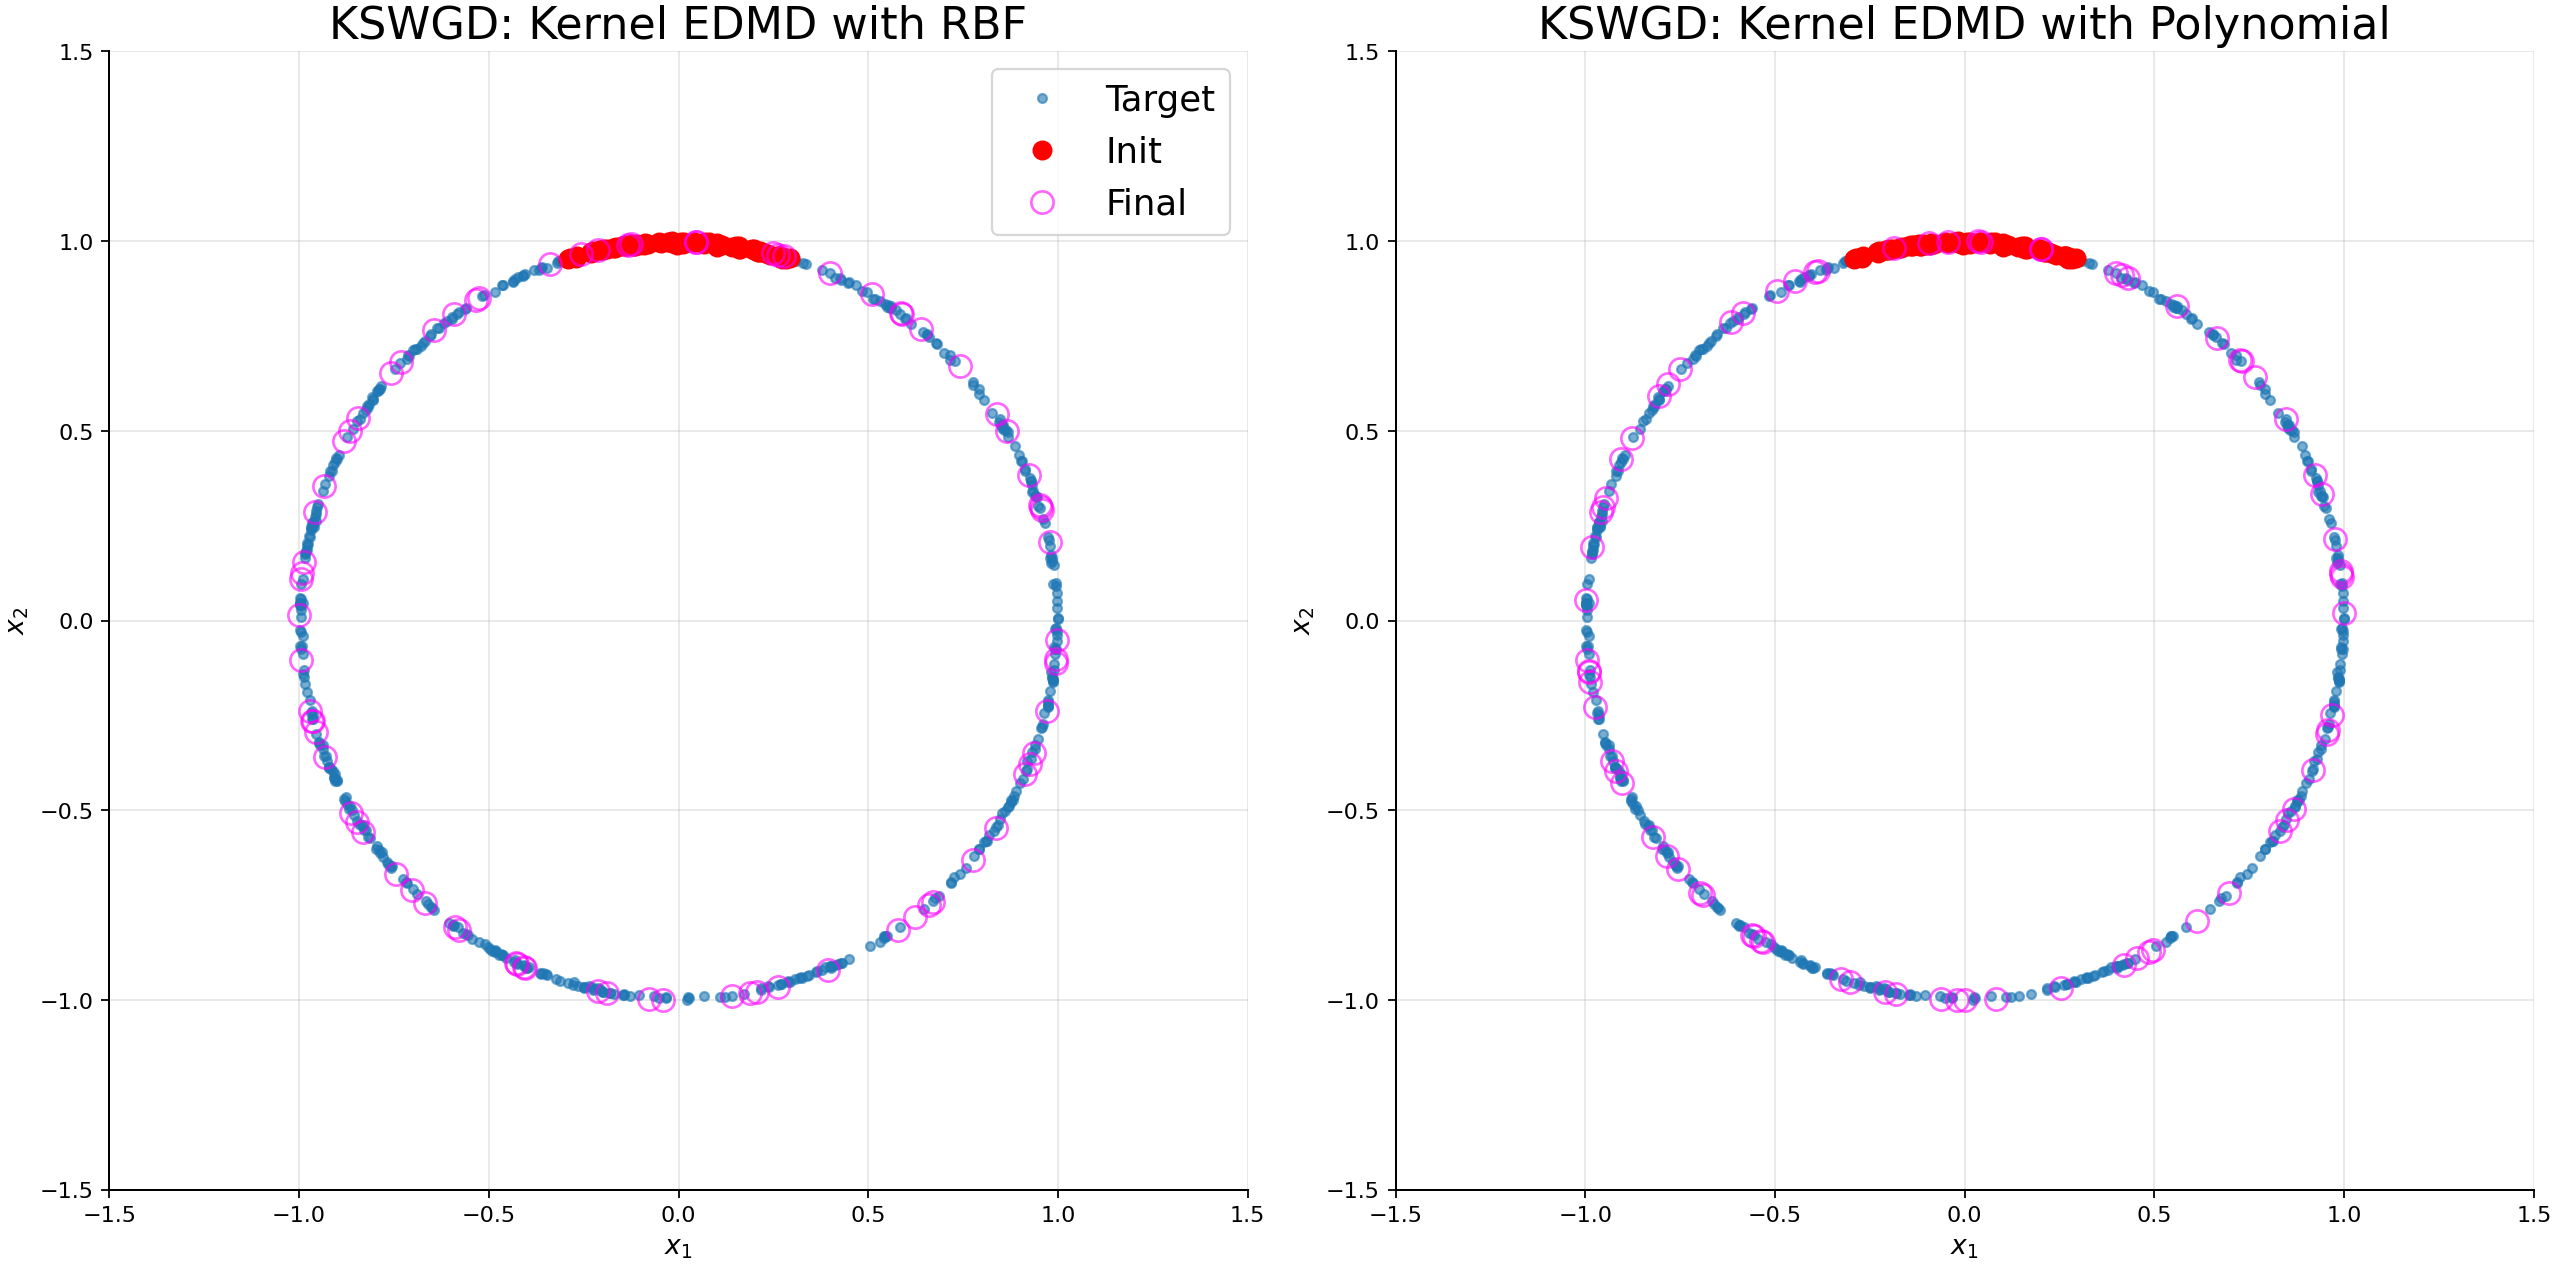

In [29]:
FIGSIZE_1X2 = (16, 8)


def _compute_kernel_edmd_transport_for_plot(compare_kernel_type, initial_positions):
    sq_tar_cmp = np.sum(X_tar ** 2, axis=1)
    H_cmp = sq_tar_cmp[:, None] + sq_tar_cmp[None, :] - 2 * (X_tar @ X_tar.T)
    epsilon_cmp = 0.5 * np.median(H_cmp) / (np.log(n + 1) + 1e-12)
    length_scale_cmp = np.sqrt(np.median(H_cmp))

    if compare_kernel_type == 1:
        compare_kernel_name = "RBF"
        K_xx_cmp = kernel1_rbf(X_tar, X_tar, epsilon_cmp)
        K_xy_cmp = kernel1_rbf(X_tar, X_tar_next, epsilon_cmp)
    elif compare_kernel_type == 5:
        compare_kernel_name = "Polynomial"
        degree_cmp = globals().get('poly_degree', 10)
        coef0_cmp = globals().get('poly_coef0', 1.0)
        gamma_cmp = globals().get('poly_gamma', 1.0 / d)
        K_xx_cmp = kernel5_polynomial(X_tar, X_tar, degree=degree_cmp, coef0=coef0_cmp, gamma=gamma_cmp)
        K_xy_cmp = kernel5_polynomial(X_tar, X_tar_next, degree=degree_cmp, coef0=coef0_cmp, gamma=gamma_cmp)
    else:
        raise ValueError('This comparison cell only supports RBF and Polynomial kernels.')

    gamma_ridge_cmp = 1e-6
    evals_kxx_cmp, Q_kxx_cmp = eigh(K_xx_cmp)
    evals_kxx_cmp = np.clip(evals_kxx_cmp, 0.0, None)
    inv_evals_cmp = 1.0 / (evals_kxx_cmp + gamma_ridge_cmp)
    data_kernel_cmp = K_xy_cmp @ (Q_kxx_cmp @ (np.diag(inv_evals_cmp) @ Q_kxx_cmp.T))
    data_kernel_cmp = np.nan_to_num(data_kernel_cmp, nan=0.0, posinf=0.0, neginf=0.0)
    minK_cmp = float(np.min(data_kernel_cmp))
    if minK_cmp < 0.0:
        data_kernel_cmp = data_kernel_cmp - minK_cmp + 1e-12

    p_x_cmp = np.sqrt(np.sum(data_kernel_cmp, axis=1))
    p_y_cmp = p_x_cmp.copy()
    data_kernel_norm_cmp = data_kernel_cmp / p_x_cmp[:, None] / p_y_cmp[None, :]
    D_y_cmp = np.sum(data_kernel_norm_cmp, axis=0)
    rw_kernel_cmp = 0.5 * (data_kernel_norm_cmp / D_y_cmp + data_kernel_norm_cmp / D_y_cmp[:, None])

    evals_rw_cmp, evecs_rw_cmp = eigh(rw_kernel_cmp)
    phi_cmp = evecs_rw_cmp[:, ::-1]
    lambda_ns_cmp = evals_rw_cmp[::-1]

    tol_cmp = 1e-6
    lambda_ns_cmp = np.where(lambda_ns_cmp < tol_cmp, 0.0, lambda_ns_cmp)
    above_tol_cmp = n - np.sum(lambda_ns_cmp < tol_cmp)

    lambda_cmp = -lambda_ns_cmp + 1
    inv_lambda_cmp = np.zeros_like(lambda_cmp)
    inv_lambda_cmp[1:] = 1 / lambda_cmp[1:]
    inv_lambda_cmp = inv_lambda_cmp * epsilon_cmp

    reg_cmp = 0.001
    lambda_ns_inv_cmp = np.zeros_like(lambda_ns_cmp)
    mask_cmp = lambda_ns_cmp >= tol_cmp
    lambda_ns_inv_cmp[mask_cmp] = epsilon_cmp / (lambda_ns_cmp[mask_cmp] + reg_cmp)
    lambda_ns_s_ns_cmp = lambda_ns_inv_cmp * inv_lambda_cmp * lambda_ns_inv_cmp
    lambda_ns_s_ns_cmp = lambda_ns_s_ns_cmp[:above_tol_cmp]

    p_tar_cmp = np.sum(data_kernel_cmp, axis=0)
    D_cmp = np.sum(data_kernel_cmp / np.sqrt(p_tar_cmp) / np.sqrt(p_tar_cmp)[:, None], axis=1)

    m_cmp = initial_positions.shape[0]
    x_cmp = np.zeros((m_cmp, d, iter), dtype=np.float64)
    x_cmp[:, :, 0] = initial_positions

    if USE_GPU:
        X_tar_gpu = cp.asarray(X_tar)
        p_tar_gpu = cp.asarray(p_tar_cmp)
        sq_tar_gpu = cp.asarray(sq_tar_cmp)
        D_gpu = cp.asarray(D_cmp)
        phi_gpu = cp.asarray(phi_cmp[:, :above_tol_cmp])
        lambda_ns_s_ns_gpu = cp.asarray(lambda_ns_s_ns_cmp)
        x_cmp_gpu = cp.asarray(x_cmp)
        diag_lambda_gpu = cp.diag(lambda_ns_s_ns_gpu)

        for t in range(iter - 1):
            x_slice = x_cmp_gpu[:, :, t]
            grad_matrix = grad_ker1(x_slice, X_tar_gpu, p_tar_gpu, sq_tar_gpu, D_gpu, epsilon_cmp)
            cross_matrix = K_tar_eval(X_tar_gpu, x_slice, p_tar_gpu, sq_tar_gpu, D_gpu, epsilon_cmp)

            sum_x_gpu = cp.zeros((m_cmp, d))
            for i in range(d):
                sum_x_gpu[:, i] = cp.sum(
                    grad_matrix[:, :, i] @ phi_gpu @ diag_lambda_gpu @ phi_gpu.T @ cross_matrix,
                    axis=1
                )

            x_proposed = x_slice - (h / m_cmp) * sum_x_gpu
            x_norm_proposed = cp.sqrt(cp.sum(x_proposed ** 2, axis=1, keepdims=True))
            x_cmp_gpu[:, :, t + 1] = x_proposed / (x_norm_proposed + 1e-12)

        x_cmp = cp.asnumpy(x_cmp_gpu)
    else:
        diag_lambda_cmp = np.diag(lambda_ns_s_ns_cmp)
        sum_x_cmp = np.zeros((m_cmp, d))
        for t in range(iter - 1):
            grad_matrix = grad_ker1(x_cmp[:, :, t], X_tar, p_tar_cmp, sq_tar_cmp, D_cmp, epsilon_cmp)
            cross_matrix = K_tar_eval(X_tar, x_cmp[:, :, t], p_tar_cmp, sq_tar_cmp, D_cmp, epsilon_cmp)
            for i in range(d):
                sum_x_cmp[:, i] = np.sum(
                    grad_matrix[:, :, i] @ phi_cmp[:, :above_tol_cmp] @ diag_lambda_cmp @ phi_cmp[:, :above_tol_cmp].T @ cross_matrix,
                    axis=1
                )

            x_proposed = x_cmp[:, :, t] - h / m_cmp * sum_x_cmp
            x_norm_proposed = np.sqrt(np.sum(x_proposed ** 2, axis=1, keepdims=True))
            x_cmp[:, :, t + 1] = x_proposed / (x_norm_proposed + 1e-12)

    return compare_kernel_name, x_cmp


x_init_for_compare = x_t[:, :, 0].copy()
rbf_label, x_t_rbf = _compute_kernel_edmd_transport_for_plot(1, x_init_for_compare)

if kernel_name == 'Polynomial':
    polynomial_label, x_t_polynomial = 'Polynomial', x_t
else:
    polynomial_label, x_t_polynomial = _compute_kernel_edmd_transport_for_plot(5, x_init_for_compare)

plot_results = [(rbf_label, x_t_rbf), (polynomial_label, x_t_polynomial)]

if d == 2:
    fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_1X2, constrained_layout=True)
    for idx, (ax, (label, x_plot)) in enumerate(zip(axes, plot_results)):
        ax.plot(X_tar[:, 0], X_tar[:, 1], 'o', markersize=4, alpha=0.6, label='Target')
        ax.plot(x_plot[:, 0, 0], x_plot[:, 1, 0], 'o', markersize=8, color='red', label='Init')
        ax.plot(x_plot[:, 0, -1], x_plot[:, 1, -1], 'o', markersize=10, markerfacecolor='none', markeredgecolor='magenta', markeredgewidth=1.2, alpha=0.6, label='Final')
        if idx == 0:
            ax.legend(fontsize=16, loc='upper right')
        ax.set_title(f'KSWGD: Kernel EDMD with {label}', fontsize=20)
        ax.set_xlabel('$x_1$')
        ax.set_ylabel('$x_2$')
        ax.set_aspect('equal', adjustable='box')
        ax.set_xlim(-1.5, 1.5)
        ax.set_ylim(-1.5, 1.5)
        ax.grid(True, alpha=0.3)
    plt.show()
else:
    from mpl_toolkits.mplot3d import Axes3D

    fig = plt.figure(figsize=FIGSIZE_1X2, constrained_layout=True)
    for idx, (label, x_plot) in enumerate(plot_results):
        ax = fig.add_subplot(1, 2, idx + 1, projection='3d')
        ax.scatter(X_tar[:, 0], X_tar[:, 1], X_tar[:, 2], s=20, alpha=0.6, label='Target')
        ax.scatter(x_plot[:, 0, 0], x_plot[:, 1, 0], x_plot[:, 2, 0], s=50, marker='o', color='red', label='Init')
        ax.scatter(x_plot[:, 0, -1], x_plot[:, 1, -1], x_plot[:, 2, -1], s=100, marker='o', facecolors='none', edgecolors='green', linewidths=0.8, alpha=0.5, label='Final')
        if idx == 0:
            ax.legend(fontsize=16, loc='upper right')
        ax.set_title(f'3D Results - Kernel EDMD with {label}', fontsize=20)
    plt.show()


## 17. Scatter Matrix Analysis

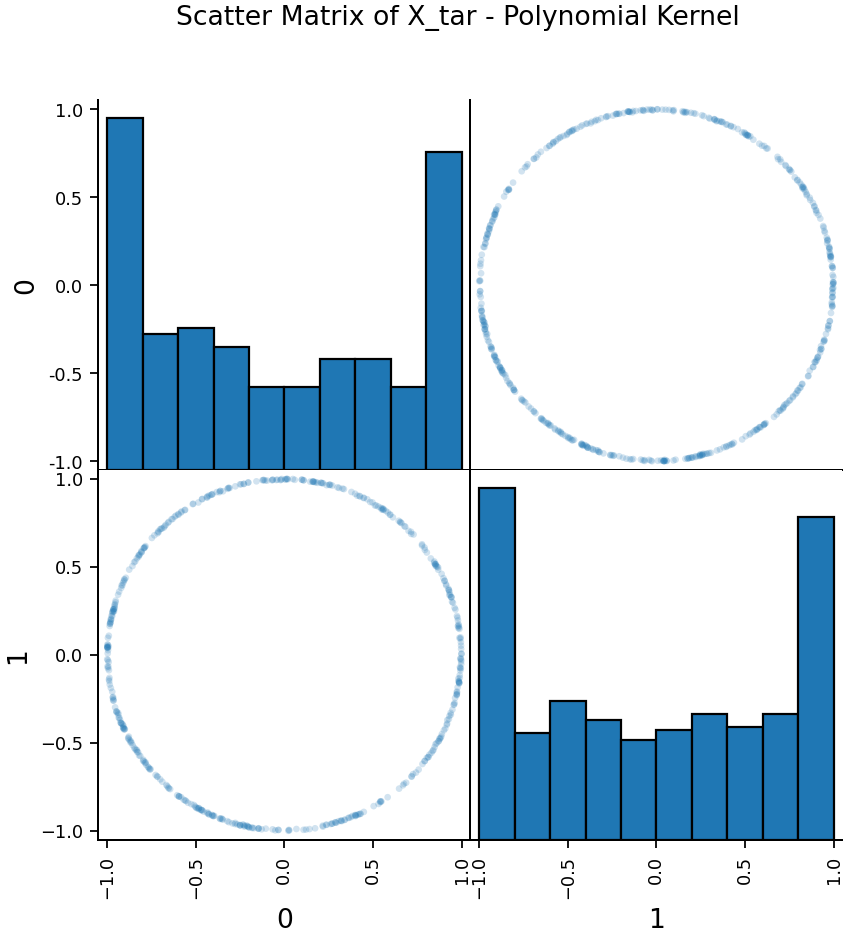

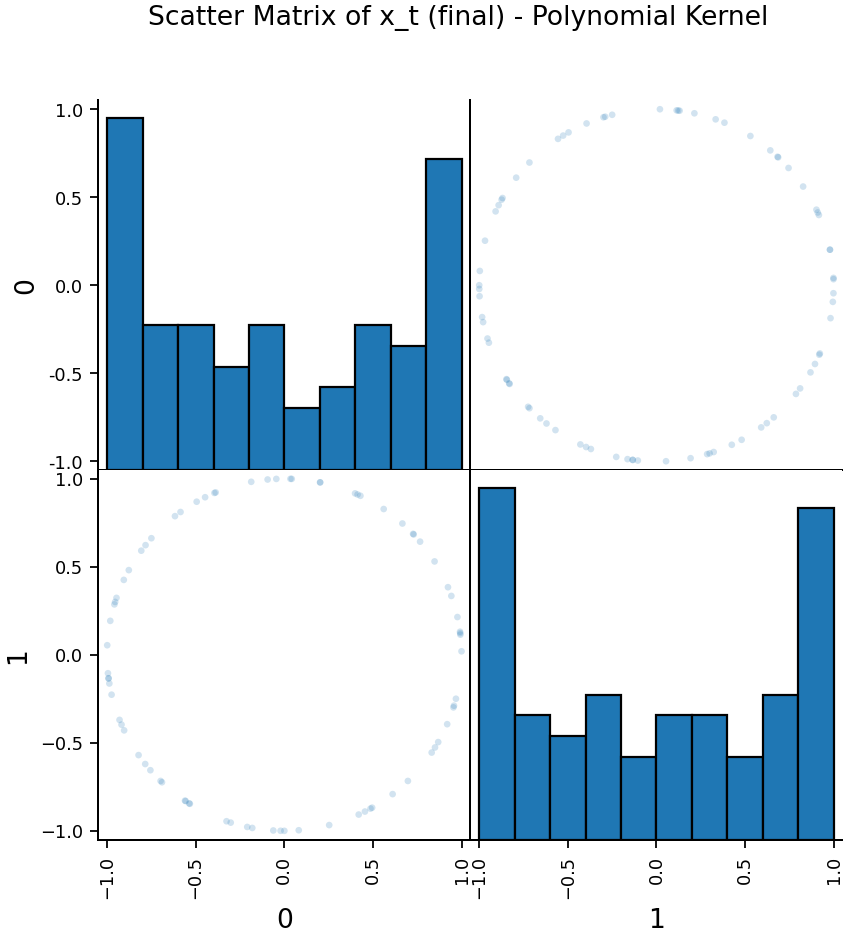

In [30]:
pd.plotting.scatter_matrix(
    pd.DataFrame(X_tar),
    alpha=0.2,
    figsize=(6, 6),
    diagonal='hist',
    hist_kwds={'edgecolor': 'black'}
)
plt.suptitle(f'Scatter Matrix of X_tar - {kernel_name} Kernel')
plt.show()

pd.plotting.scatter_matrix(
    pd.DataFrame(x_t[:, :, -1]),
    alpha=0.2,
    figsize=(6, 6),
    diagonal='hist',
    hist_kwds={'edgecolor': 'black'}
)
plt.suptitle(f'Scatter Matrix of x_t (final) - {kernel_name} Kernel')
plt.show()